# Análise de Churn — BankChurners

Projeto de análise e previsão de churn (cancelamento de clientes) de um banco, usando o dataset BankChurners. Inclui um notebook com todo o pipeline de dados + modelo, e um dashboard estático em HTML para visualização dos resultados.
Notebook organizado em etapas: carga e limpeza dos dados, análise exploratória, treinamento de um modelo de Regressão Logística e avaliação do impacto financeiro das previsões.

## 1. Importação de bibliotecas

Importa as bibliotecas que serão utilizadas no projeto, algumas linhas importadas ajudam na análise, StandardScaler padroniza das variáveis numéricas, "from sklearn.linear_model import LogisticRegression" é importada o algoritmo de regressão linear. "pd.set_option('display.max_columns', None)" remova o limite de colunas exibidas, facilitando a visão geral do csv. Por fim o tema escolhido foi o whitegrid pois permite uma melhor visualização de gráficos.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


## 2. Carregamento e limpeza dos dados

Carrega o CSV, remove as colunas geradas automaticamente pelo classificador Naive Bayes (que não fazem parte dos dados originais, colunas dispensáveis para qualquer tipo de projeto, o autor deste csv recomenda a exclusão destas colunas no kaggle) e cria a coluna alvo `Churn` a partir de `Attrition_Flag`.

In [4]:
df = pd.read_csv('BankChurners.csv')

colunas_para_remover = [
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]
df = df.drop(columns=colunas_para_remover)

df["Churn"] = df["Attrition_Flag"].apply(lambda x: 1 if x == "Attrited Customer" else 0)
df = df.drop(columns=["Attrition_Flag"])

df.head()


,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,768805383,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,818770008,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,713982108,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,769911858,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,709106358,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


## 3. Análise exploratória (EDA)

Comparação de duas variáveis-chave entre clientes ativos (`Churn = 0`) e clientes que cancelaram (`Churn = 1`):
- Quantidade total de transações no ano
- Meses de inatividade no último ano

C:\Users\enzop\AppData\Local\Temp\ipykernel_14296\1119695236.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Total_Trans_Ct', data=df, ax=ax[0], palette='Set2')
C:\Users\enzop\AppData\Local\Temp\ipykernel_14296\1119695236.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Months_Inactive_12_mon', data=df, ax=ax[1], palette='Set2')


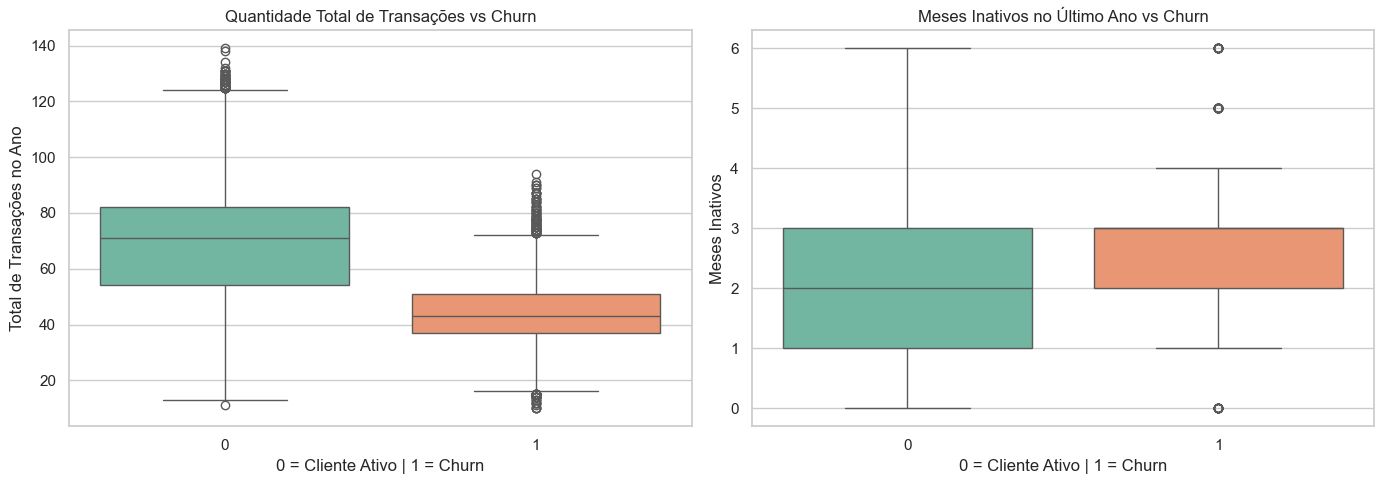

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Relação entre o Churn e a Quantidade de Transações
sns.boxplot(x='Churn', y='Total_Trans_Ct', data=df, ax=ax[0], palette='Set2')
ax[0].set_title('Quantidade Total de Transações vs Churn')
ax[0].set_xlabel('0 = Cliente Ativo | 1 = Churn')
ax[0].set_ylabel('Total de Transações no Ano')

# Gráfico 2: Relação entre o Churn e os Meses Inativos
sns.boxplot(x='Churn', y='Months_Inactive_12_mon', data=df, ax=ax[1], palette='Set2')
ax[1].set_title('Meses Inativos no Último Ano vs Churn')
ax[1].set_xlabel('0 = Cliente Ativo | 1 = Churn')
ax[1].set_ylabel('Meses Inativos')

plt.tight_layout()
plt.show()


Com este gráficos podemos concluir que **clientes que cancelam suas contas transacionam menos e ficam mais tempo inativos que clientes que permanecem utilizando serviços do banco.**


## 4. Pré-processamento

Converte as colunas categóricas (tipo gênero, nível de educação, categoria de cartão) em colunas binárias (0/1), porque a Regressão Logística só entende números. Separa os dados em X e Y, para ocorrer a previsão. O bloco serve para entregar os dados prontos, numéricos, separados e na escala certa pra alimentar o modelo.

In [6]:
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Treinamento do modelo

Regressão Logística com `class_weight='balanced'` para compensar o desbalanceamento entre clientes ativos e em churn. Treino e teste do modelo proposto.

In [7]:
modelo = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modelo.fit(X_train_scaled, y_train)

previsoes = modelo.predict(X_test_scaled)

print("Modelo treinado")


Modelo treinado


Esse código é o momento de corrigir a prova que o modelo fez no passo anterior. Ele gera a precisão do algoritmo para mostrar exatamente onde ele acertou e que tipo de erros ele cometeu, parte essencial para validação do método executado.

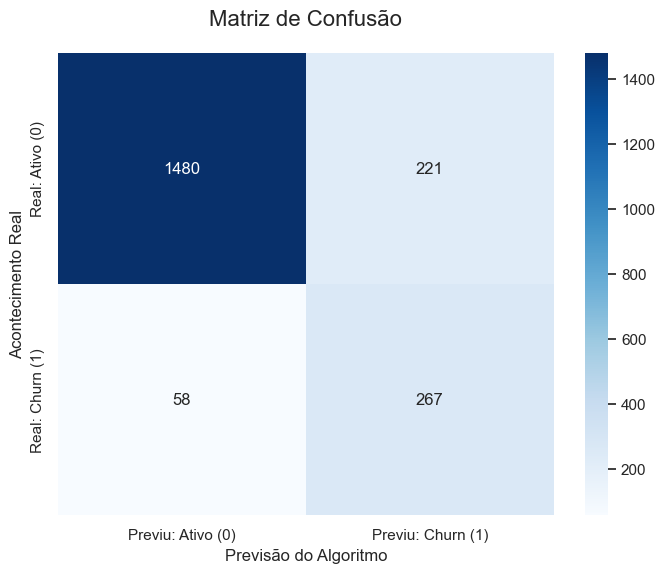


--- Relatório de Desempenho do Modelo ---
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      1701
           1       0.55      0.82      0.66       325

    accuracy                           0.86      2026
   macro avg       0.75      0.85      0.79      2026
weighted avg       0.90      0.86      0.87      2026



In [8]:
matriz = confusion_matrix(y_test, previsoes)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previu: Ativo (0)', 'Previu: Churn (1)'],
            yticklabels=['Real: Ativo (0)', 'Real: Churn (1)'])

plt.title('Matriz de Confusão', pad=20, size=16)
plt.ylabel('Acontecimento Real')
plt.xlabel('Previsão do Algoritmo')
plt.show()

print("\n--- Relatório de Desempenho do Modelo ---")
print(classification_report(y_test, previsoes))


## 7. Impacto financeiro

O modelo nos deu clareza cirúrgica. Com a lista dos clientes detectados, não precisamos mais dar descontos ou benefícios às cegas para toda a base. Podemos pegar uma pequena fatia do Lucro Retido e usá-la em campanhas de fidelização exclusivas apenas para os clientes que o modelo apontou como risco. É investimento em retenção com eficiência máxima e desperdício zero.

In [9]:
resultados = X_test.copy()
resultados['Real_Churn'] = y_test
resultados['Previsao_Churn'] = previsoes
resultados['Volume_Transacoes'] = df.loc[X_test.index, 'Total_Trans_Amt']

# Clientes que iriam sair e o modelo detectou a tempo
clientes_salvos = resultados[(resultados['Real_Churn'] == 1) & (resultados['Previsao_Churn'] == 1)]
volume_salvo = clientes_salvos['Volume_Transacoes'].sum()
lucro_retido = volume_salvo * 0.02

# Clientes que saíram e o modelo não detectou (pontos cegos)
clientes_perdidos = resultados[(resultados['Real_Churn'] == 1) & (resultados['Previsao_Churn'] == 0)]
volume_perdido = clientes_perdidos['Volume_Transacoes'].sum()
lucro_perdido = volume_perdido * 0.02

print("=== RELATÓRIO DE IMPACTO FINANCEIRO DO MODELO ===")
print(f"Volume Financeiro em Risco Detectado: $ {volume_salvo:,.2f}")
print(f"Lucro Retido (2% de taxa): $ {lucro_retido:,.2f}")
print("-" * 45)
print(f"Volume Financeiro Perdido (Pontos Cegos): $ {volume_perdido:,.2f}")
print(f"Lucro Perdido: $ {lucro_perdido:,.2f}")


=== RELATÓRIO DE IMPACTO FINANCEIRO DO MODELO ===
Volume Financeiro em Risco Detectado: $ 809,518.00
Lucro Retido (2% de taxa): $ 16,190.36
---------------------------------------------
Volume Financeiro Perdido (Pontos Cegos): $ 266,231.00
Lucro Perdido: $ 5,324.62
